# A simple standard Brownian motion project
### by Patrick Salim
#### May 2026

## Section 1
We shall make use of concepts from basic probability and real analysis to construct a standard Brownian motion without drift. A Brownian Motion is a martingale, which is a stochastic process adapted to a filtration, wherein the conditional expectation of the stochastic process given the information at an earlier time is exactly the same as the expectation at that earlier time, i.e., the expectation is always the same. Colloquially, this is a "fair game". In financial mathematics, running many simulations of such a process is a method of pricing options, such a method is understood to be a Monte-Carlo simulation. The following definition suffices as an introduction.

*Definition* Let $(\Omega,\mathcal{F},\mathbb{P})$ be a probability space. If for each $\omega \in \Omega$, there exists a continuous function $W(t)$ for some nonnegative $t$ that satisfies $W(0)=0$ and that depends on $\omega$, then $W(t)$ is a Brownian motion, if for all $0=t_0<t_1<...<t_m$ the increments $W(t_n)-W(t_{n-1})$ for all $n \in {1,2,...,m}$ are independent and each of these increments is normally distributed with expectation zero and variance equal to the length of the increment. Note that this implies the increments are i.i.d if the increments are uniform.

We can now construct a Brownian motion by writing a recursive relation $W(t_{n+1})=W(t_n)+X_{n+1}\sqrt{t_{n+1}-t_n}$, where every $X_{n}$ is a normally distributed sample with mean zero and variance one. This ensures that the expectation of an increment is always zero and that variance is always the length of the increment.

To apply this to code, we make use of the NumPy library to generate $k$ paths. We start by sampling $k \times N$ draws, where $N$ is the time steps, from a standard normal distribution. In addition to this, we shall also import Matplotlib, Pandas, and Seaborn.

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

Now we shall use a random number generator via NumPy.

In [60]:
rng = np.random.default_rng(42)

We may now specify the quantity of paths and time steps per path, which for the purpose of this project shall be 50 and 5000, respectively. In this section, we shall assume no drift (mu) and variance one.

In [61]:
paths = 50
points = 5000
mu, sigma = 0.0, 1.0

We shall now utilise the random number generator for the normally distributed sample $X$.

In [62]:
X = rng.normal(mu, sigma, (paths, points))

For the purpose of this project we shall choose $t_0=0$ and $t_m=1$, and choose the increments to be uniform.

In [63]:
interval = [0.0, 1.0]
dt = (interval[1] - interval[0]) / (points - 1)
t_axis = np.linspace(interval[0], interval[1], points)
W = np.zeros((paths, points))
for idx in range(points - 1):
    real_idx = idx + 1
    W[:, real_idx] = W[:, real_idx - 1] + X[:, real_idx] * np.sqrt(dt)

Now to plot

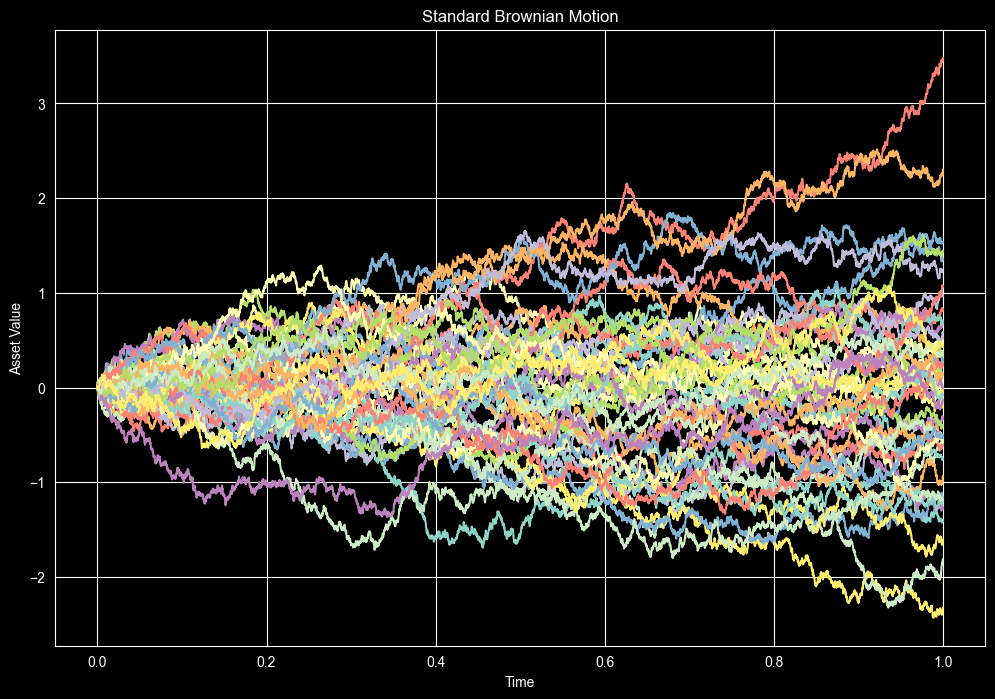

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(t_axis, W[path, :])
ax.set_title("Standard Brownian Motion")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()

By the Strong Law of Large Numbers (Kolmogorov's Law), the sample mean $W(t)/t$ shall converge almost surely to the expectation (zero) as t goes to infinity. That is, $\mathbb{P}{W(t)/t \nrightarrow 0}=0$. This is why the bulk of the paths cluster around the asset value of zero even at Time = 1.0, as per the usual behaviour of standard Brownian motion with no drift.

Indeed, by the Central Limit Theorem, the distribution of this Brownian motion shall approach normal distribution. We may see this by using Kernel Density Estimate (KDE) from Seaborn.

We first create a Pandas DataFrame of the sample path values at Time = 1.0.

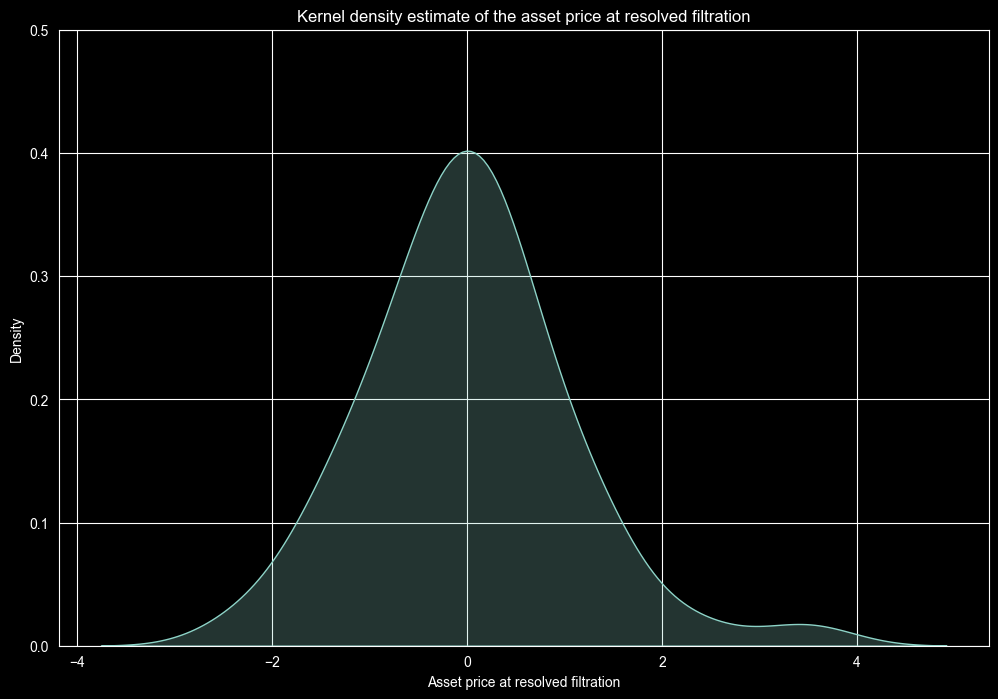

In [65]:
final_values = pd.DataFrame({'final_values': W[:, -1]})
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sns.kdeplot(data=final_values, x='final_values', fill=True, ax=ax)
ax.set_title("Kernel density estimate of the asset price at resolved filtration")
ax.set_ylim(0.0, 0.5)
ax.set_xlabel('Asset price at resolved filtration')
plt.show()

This approaches standard normal distribution. We may even compute the sample mean and volatility (standard deviation).

In [66]:
print(final_values.mean(), final_values.std())

final_values    0.009303
dtype: float64 final_values    1.045194
dtype: float64


As expected, these are relatively close to mean zero and volatility one.

## Section 2
Now we shall add constant drift and volatility not equal to one. To do this, we shall write $Y(t_{n+1})=Y(t_n)+\mu(t_{n+1}-t_n)+\sigma X_{n+1}\sqrt{t_{n+1}-t_n}$, where again every $X_{n}$ is a normally distributed sample with mean zero and variance one, $\mu$ is the constant drift, and $\sigma$ is the volatility.

For the purpose of this project, we shall choose the drift to be 4 and volatility to be 3.

In [67]:
mu_r, sigma_r = 4.0, 3.0

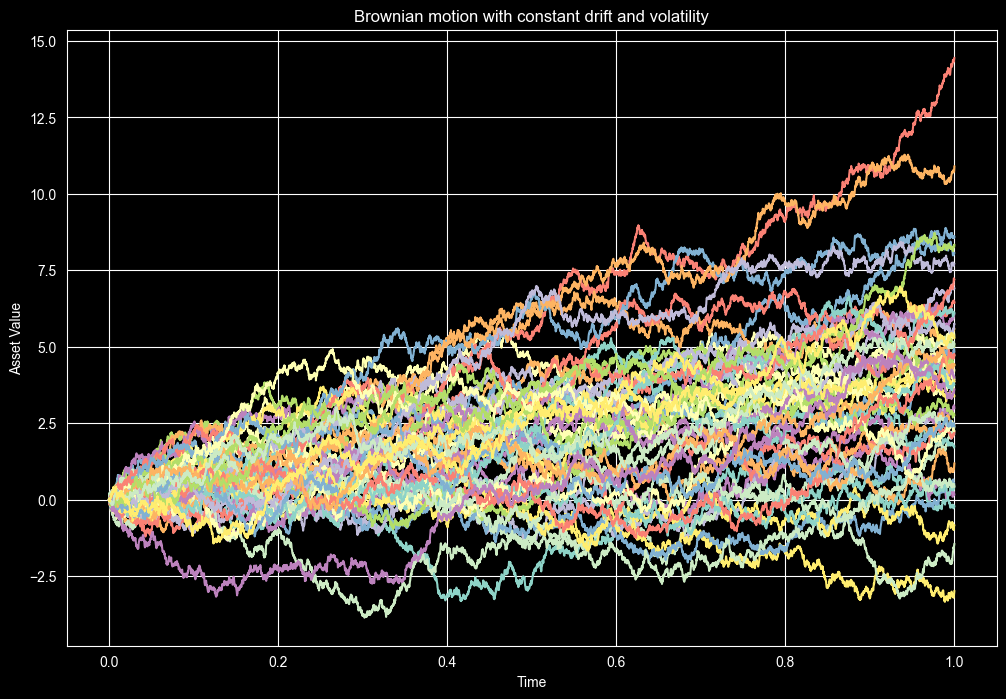

In [68]:
Y = np.zeros((paths, points))
for idx in range(points - 1):
    real_idx = idx + 1
    Y[:, real_idx] = Y[:, real_idx - 1] + mu_r * dt + sigma_r * X[:, real_idx] * np.sqrt(dt)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
for path in range(paths):
    ax.plot(t_axis, Y[path, :])
ax.set_title("Brownian motion with constant drift and volatility")
ax.set_xlabel("Time")
ax.set_ylabel("Asset Value")
plt.show()

Again, we display the KDE.

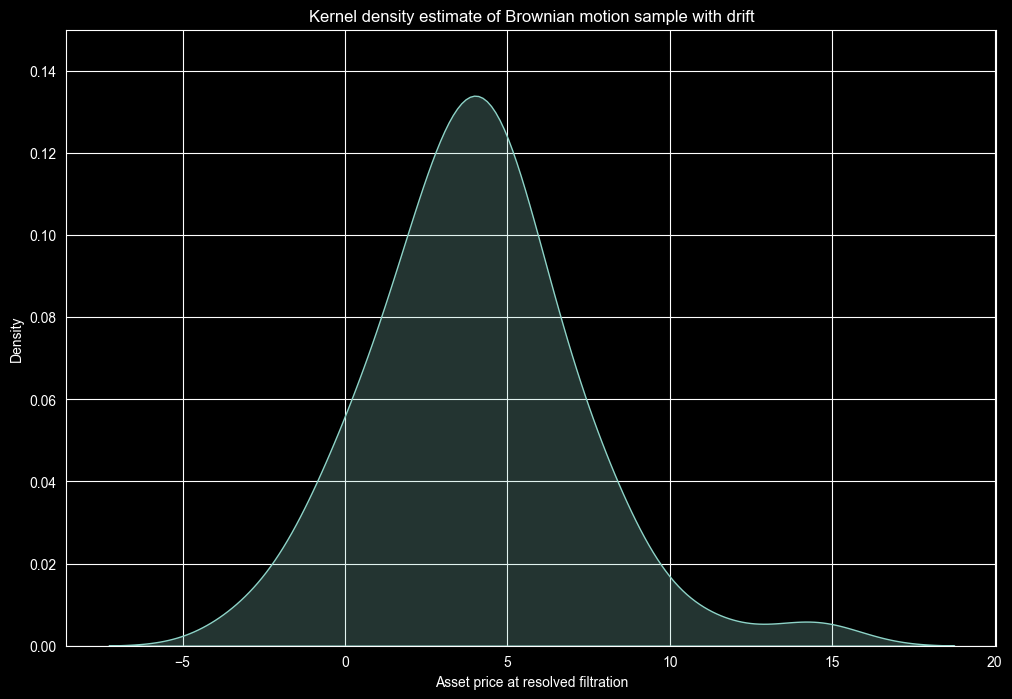

In [69]:
final_values_drift = pd.DataFrame({'final_values_drift': Y[:, -1]})
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
sns.kdeplot(data=final_values_drift, x='final_values_drift', fill=True, ax=ax)
ax.set_title("Kernel density estimate of Brownian motion sample with drift")
ax.set_ylim(0.0, 0.15)
ax.set_xlabel('Asset price at resolved filtration')
plt.show()

Again, to see the expectation and volatility:

In [70]:
print(final_values.mean(), final_values.std())

final_values    0.009303
dtype: float64 final_values    1.045194
dtype: float64


This marks the end of the simple standard Brownian motion project.